# BirdCLEF 2026 — Exploratory Data Analysis

A pre-analysis of the competition data, run **before** any modelling, to understand what we are predicting and why it is hard. Each section below maps to a subsection of the report.

**What the task actually is.** Despite the "Bird"CLEF name, the 2026 edition is a *multi-taxa* soundscape classification problem from the **Pantanal wetlands (Mato Grosso do Sul, Brazil)**. We must assign per-5-second probabilities to **234 species** spanning birds, amphibians, insects, mammals and reptiles — scored by macro-averaged ROC-AUC.

**The central difficulty (preview).** We train mostly on *focal recordings* (one clean, foreground species per clip, crowd-sourced worldwide) but are scored on *soundscapes* (noisy field recordings with several overlapping species). This **domain shift** is the theme that recurs throughout this analysis.

In [1]:
import os
import ast
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 30)
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Local competition data layout (same files as Kaggle, just a partial audio download)
DATA_DIR        = 'data'
TRAIN_CSV       = os.path.join(DATA_DIR, 'train.csv')
TAXONOMY_CSV    = os.path.join(DATA_DIR, 'taxonomy.csv')
SS_LABELS_CSV   = os.path.join(DATA_DIR, 'train_soundscapes_labels.csv')
TRAIN_AUDIO_DIR = os.path.join(DATA_DIR, 'train_audio')
SS_AUDIO_DIR    = os.path.join(DATA_DIR, 'train_soundscapes')

# Audio config — kept identical to agent.py so spectrograms match what the model sees
SAMPLE_RATE = 32000
DURATION    = 5
N_MELS      = 64
F_MAX       = 16000

print('Files present:')
for p in [TRAIN_CSV, TAXONOMY_CSV, SS_LABELS_CSV]:
    print(f'  {"OK " if os.path.exists(p) else "MISSING"} {p}')

Files present:
  OK  data/train.csv
  OK  data/taxonomy.csv
  OK  data/train_soundscapes_labels.csv


## 1. Dataset overview

Three tables drive everything:

| File | What it is |
|------|------------|
| `train.csv` | One row per **focal recording** (the bulk of training data) |
| `taxonomy.csv` | The **234 target species** and their taxonomic class |
| `train_soundscapes_labels.csv` | Labelled 5s windows of **soundscapes** — the distribution we are actually scored on |

In [2]:
train    = pd.read_csv(TRAIN_CSV)
taxonomy = pd.read_csv(TAXONOMY_CSV)
ss       = pd.read_csv(SS_LABELS_CSV)

print(f'train.csv               : {train.shape[0]:>6} recordings, {train.shape[1]} columns')
print(f'taxonomy.csv            : {taxonomy.shape[0]:>6} target species')
print(f'train_soundscapes_labels: {ss.shape[0]:>6} labelled 5s windows')
print()
print('train.csv columns:', list(train.columns))
train.head(3)

train.csv               :  35549 recordings, 15 columns
taxonomy.csv            :    234 target species
train_soundscapes_labels:   1478 labelled 5s windows

train.csv columns: ['primary_label', 'secondary_labels', 'type', 'latitude', 'longitude', 'scientific_name', 'common_name', 'class_name', 'inat_taxon_id', 'author', 'license', 'rating', 'url', 'filename', 'collection']


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat


## 2. Taxonomic composition — it is not just birds

The 234 targets span five taxonomic classes. Birds dominate, but amphibians and insects are a meaningful slice — and they sound nothing like birds (continuous insect stridulation, frog choruses), which matters for a single shared spectrogram model.

class_name
Aves        162
Amphibia     35
Insecta      28
Mammalia      8
Reptilia      1
Name: count, dtype: int64

Total target species: 234


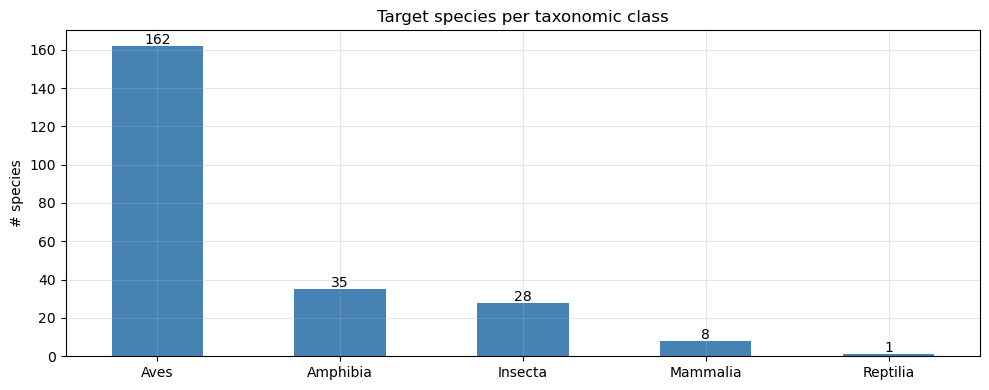

In [3]:
class_counts = taxonomy['class_name'].value_counts()
print(class_counts)
print(f'\nTotal target species: {taxonomy["primary_label"].nunique()}')

ax = class_counts.plot.bar(color='steelblue')
ax.set_title('Target species per taxonomic class')
ax.set_ylabel('# species')
ax.set_xlabel('')
for i, v in enumerate(class_counts):
    ax.text(i, v + 1, str(v), ha='center')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Class imbalance — the long tail

How many focal recordings exist per species? Crowd-sourced audio is heavily skewed: a few charismatic species have hundreds of clips, while many rare ones have only a handful. Macro ROC-AUC weights every species equally, so the **rare tail** is where most of the score is won or lost.

Recordings per species — min 1, median 125, mean 172.6, max 499
  species with <   5 recordings:  14  (7%)
  species with <  10 recordings:  25  (12%)
  species with <  20 recordings:  36  (17%)
  species with <  50 recordings:  52  (25%)


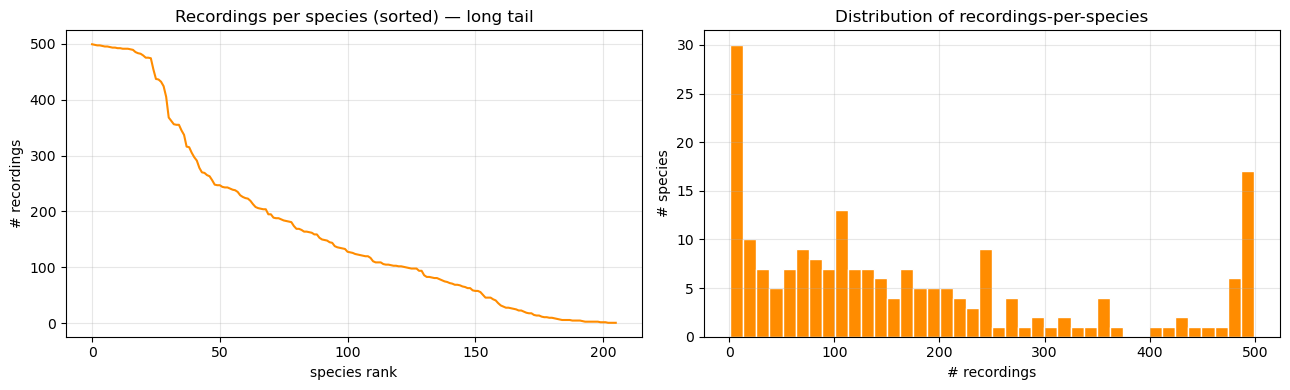

In [4]:
per_species = train['primary_label'].value_counts()

print(f'Recordings per species — min {per_species.min()}, median {int(per_species.median())}, '
      f'mean {per_species.mean():.1f}, max {per_species.max()}')
for thr in [5, 10, 20, 50]:
    n = (per_species < thr).sum()
    print(f'  species with < {thr:>3} recordings: {n:>3}  ({100*n/len(per_species):.0f}%)')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
per_species.reset_index(drop=True).plot(ax=ax[0], color='darkorange')
ax[0].set_title('Recordings per species (sorted) — long tail')
ax[0].set_xlabel('species rank'); ax[0].set_ylabel('# recordings')
ax[1].hist(per_species.values, bins=40, color='darkorange', edgecolor='white')
ax[1].set_title('Distribution of recordings-per-species')
ax[1].set_xlabel('# recordings'); ax[1].set_ylabel('# species')
plt.tight_layout(); plt.show()

In [5]:
# Cross-check: are all 234 target species actually represented in train.csv?
tax_species   = set(taxonomy['primary_label'].astype(str))
train_species = set(train['primary_label'].astype(str))
missing = tax_species - train_species
print(f'Target species: {len(tax_species)}')
print(f'Species appearing in train.csv (as primary): {len(train_species & tax_species)}')
print(f'Target species with NO focal recording as primary: {len(missing)}')
if missing:
    print('  ', sorted(missing)[:20])

# Local audio is a partial download — note the gap so spectrogram cells degrade gracefully
if os.path.isdir(TRAIN_AUDIO_DIR):
    local_dirs = len([d for d in os.listdir(TRAIN_AUDIO_DIR)
                      if os.path.isdir(os.path.join(TRAIN_AUDIO_DIR, d))])
    print(f'\nLocal train_audio/ species folders: {local_dirs} '
          f'(full dataset has audio for all targets; local copy may be partial)')

Target species: 234
Species appearing in train.csv (as primary): 206
Target species with NO focal recording as primary: 28
   ['1491113', '25073', '47158son01', '47158son02', '47158son03', '47158son04', '47158son05', '47158son06', '47158son07', '47158son08', '47158son09', '47158son10', '47158son11', '47158son12', '47158son13', '47158son14', '47158son15', '47158son16', '47158son17', '47158son18']

Local train_audio/ species folders: 206 (full dataset has audio for all targets; local copy may be partial)


## 4. Multi-label structure

Many focal clips carry **secondary labels** — other species audible in the background. This is what makes the task genuinely multi-label even before we reach the soundscapes, and it is why the model head ends in `Dense(234, activation='sigmoid')` (independent per-species probabilities) rather than softmax.

Clips with >=1 secondary label: 12.3%
Max secondary labels on one clip: 15

Distribution of secondary-label count:
_n_sec
0    31177
1     2623
2     1049
3      379
4      169
5       87
6       35
7       11
Name: count, dtype: int64


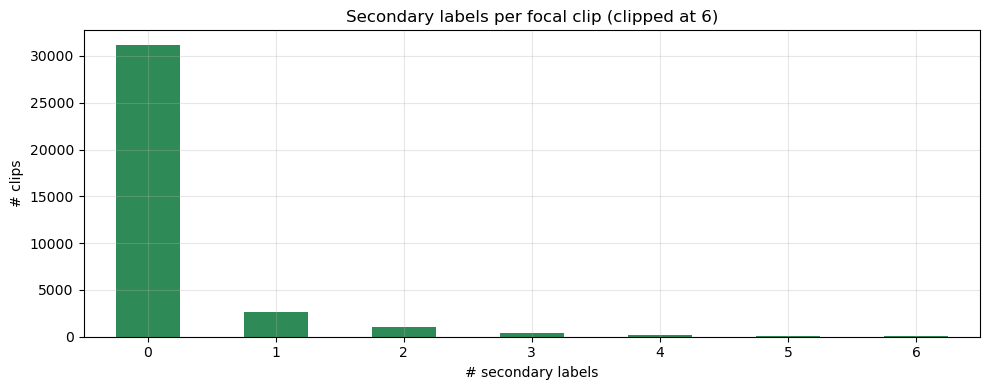

In [6]:
def parse_list(x):
    """secondary_labels is a stringified python list, e.g. \"['22961', '23158']\"."""
    if pd.isna(x):
        return []
    try:
        v = ast.literal_eval(x)
        return v if isinstance(v, list) else []
    except (ValueError, SyntaxError):
        return []

train['_sec'] = train['secondary_labels'].apply(parse_list)
train['_n_sec'] = train['_sec'].apply(len)

has_sec = (train['_n_sec'] > 0).mean()
print(f'Clips with >=1 secondary label: {100*has_sec:.1f}%')
print(f'Max secondary labels on one clip: {train["_n_sec"].max()}')
print('\nDistribution of secondary-label count:')
print(train['_n_sec'].value_counts().sort_index().head(8))

ax = train['_n_sec'].clip(upper=6).value_counts().sort_index().plot.bar(color='seagreen')
ax.set_title('Secondary labels per focal clip (clipped at 6)')
ax.set_xlabel('# secondary labels'); ax.set_ylabel('# clips')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 5. Geography & domain shift

The test soundscapes come from a **single fixed region** — the Pantanal (lat ≈ −21.6…−16.5, lon ≈ −57.6…−55.9). The focal training clips are crowd-sourced **worldwide**. Plotting recording coordinates shows how little of the training data actually originates near the scored region: a core driver of the train→test gap.

Clips with coordinates : 35549 / 35549
Clips inside Pantanal box: 847 (2.4% of geo-located clips)


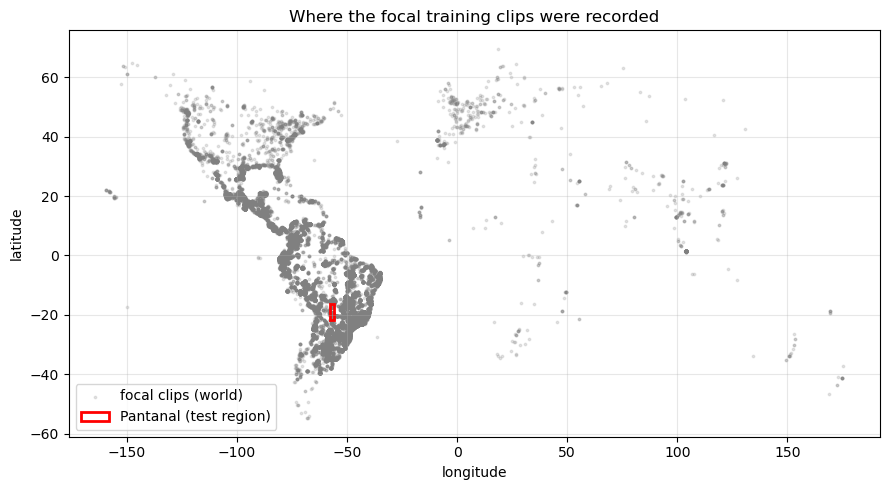

In [7]:
# Pantanal recorder bounding box (from data/recording_location.txt)
LAT_MIN, LAT_MAX = -21.6, -16.5
LON_MIN, LON_MAX = -57.6, -55.9

geo = train.dropna(subset=['latitude', 'longitude'])
in_box = ((geo['latitude'].between(LAT_MIN, LAT_MAX)) &
          (geo['longitude'].between(LON_MIN, LON_MAX)))
print(f'Clips with coordinates : {len(geo)} / {len(train)}')
print(f'Clips inside Pantanal box: {in_box.sum()} ({100*in_box.mean():.1f}% of geo-located clips)')

plt.figure(figsize=(9, 5))
plt.scatter(geo['longitude'], geo['latitude'], s=3, alpha=0.2, color='gray', label='focal clips (world)')
plt.gca().add_patch(plt.Rectangle((LON_MIN, LAT_MIN), LON_MAX-LON_MIN, LAT_MAX-LAT_MIN,
                                  fill=False, edgecolor='red', lw=2, label='Pantanal (test region)'))
plt.title('Where the focal training clips were recorded')
plt.xlabel('longitude'); plt.ylabel('latitude'); plt.legend(loc='lower left')
plt.tight_layout(); plt.show()

## 6. Recording metadata & quality

`rating` (crowd quality score), `collection` (source), and `type` (vocalisation type / call vs song) tell us how clean and consistent the training signal is. Low-rated and heterogeneous sources add label noise.

Clips with rating 0 (unrated/low): 36.1%


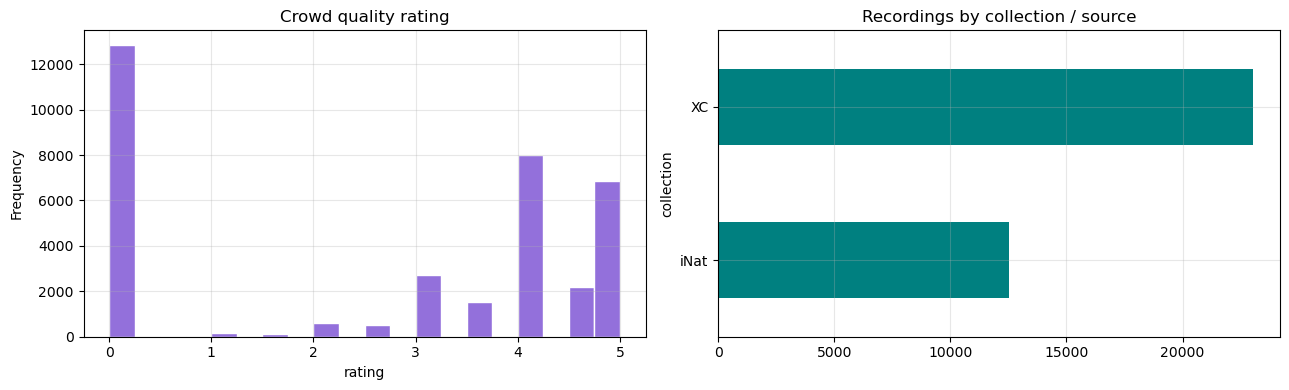


Most common recording "type" values:
type
[]                   12975
['song']             10376
['call']              6205
['call', ' song']     1458
['flight call']        711
['alarm call']         423
['dawn song']          216
['uncertain']          191
['duet', ' song']      171
['canto']              171
Name: count, dtype: int64


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

if 'rating' in train:
    train['rating'].plot.hist(bins=20, ax=ax[0], color='mediumpurple', edgecolor='white')
    ax[0].set_title('Crowd quality rating'); ax[0].set_xlabel('rating')
    zero = (train['rating'] == 0).mean()
    print(f'Clips with rating 0 (unrated/low): {100*zero:.1f}%')

if 'collection' in train:
    train['collection'].value_counts().head(8).plot.barh(ax=ax[1], color='teal')
    ax[1].set_title('Recordings by collection / source'); ax[1].invert_yaxis()

plt.tight_layout(); plt.show()

if 'type' in train:
    print('\nMost common recording "type" values:')
    print(train['type'].fillna('(none)').value_counts().head(10))

## 7. The soundscape labels — the distribution we are scored on

This is the most important table for understanding the target. Each row is a labelled 5s window of a Pantanal soundscape, with `primary_label` holding **`;`-separated species** present in that window. Compared with focal clips, soundscape windows are **denser** (multiple simultaneous species) and reflect the real co-occurrence structure we must reproduce at inference.

Labelled windows           : 1478
Distinct soundscape files  : 66
Species per window — mean 4.22, median 4, max 10
Empty / no-species windows : 0


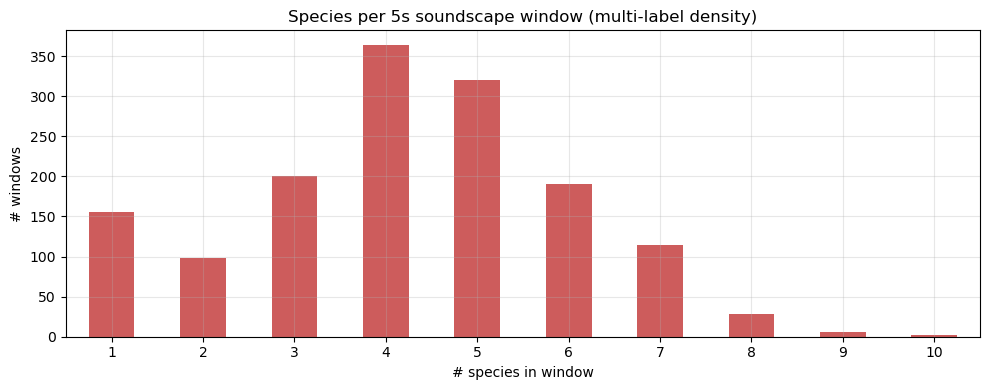

In [9]:
# Each window's primary_label is a ';'-separated set of species present
ss['_labels'] = ss['primary_label'].astype(str).str.split(';')
ss['_n'] = ss['_labels'].apply(lambda L: len([x for x in L if x and x != 'nan']))

print(f'Labelled windows           : {len(ss)}')
print(f'Distinct soundscape files  : {ss["filename"].nunique()}')
print(f'Species per window — mean {ss["_n"].mean():.2f}, median {int(ss["_n"].median())}, max {ss["_n"].max()}')
print(f'Empty / no-species windows : {(ss["_n"] == 0).sum()}')

ax = ss['_n'].value_counts().sort_index().plot.bar(color='indianred')
ax.set_title('Species per 5s soundscape window (multi-label density)')
ax.set_xlabel('# species in window'); ax.set_ylabel('# windows')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

In [10]:
# Which species actually show up in the scored soundscapes, vs the 234 targets?
ss_species = Counter()
for labels in ss['_labels']:
    for s in labels:
        if s and s != 'nan':
            ss_species[s] += 1

ss_set = set(ss_species)
print(f'Distinct species observed in labelled soundscapes: {len(ss_set)} / {len(tax_species)} targets')
print(f'Target species NEVER seen in labelled soundscapes : {len(tax_species - ss_set)}')
print('\nTop 15 most frequent species in soundscapes:')
for sp, c in ss_species.most_common(15):
    name = taxonomy.loc[taxonomy['primary_label'].astype(str) == sp, 'common_name']
    print(f'  {sp:>10}  {c:>4} windows  {name.iloc[0] if len(name) else "?"}')

Distinct species observed in labelled soundscapes: 75 / 234 targets
Target species NEVER seen in labelled soundscapes : 159

Top 15 most frequent species in soundscapes:
       65380   666 windows  Dwarf Tree Frog
      517063   626 windows  Southern Orange-legged Leaf Frog
       22973   426 windows  Whistling Grass Frog
      555146   420 windows  Chaco Tree Frog
       23158   350 windows  Pale-legged Weeping Frog
       24279   346 windows  Lesser Snouted Tree Frog
       24321   344 windows  Mato Grosso Snouted Tree Frog
       22967   310 windows  Marbled White-lipped Frog
       66971   298 windows  Paraguayan Swimming Frog
  47158son25   168 windows  Insect sonotype25
     1491113   158 windows  Guaraní leaf-litter frog
     chacha1   130 windows  Chaco Chachalaca
      whtdov   126 windows  White-tipped Dove
  47158son07    96 windows  Insect sonotype07
  47158son17    86 windows  Insect sonotype17


## 8. Signal inspection — focal clip vs soundscape

Finally, look at the raw audio the model sees. We render mel-spectrograms with **the exact config from `agent.py`** (32 kHz, 64 mel bins, 5s windows). The contrast — a clean isolated call vs a dense noisy soundscape — is the domain shift made visible.

In [11]:
# librosa is the same dependency the agent and submission notebook use
try:
    import librosa, librosa.display
    HAVE_LIBROSA = True
except ImportError:
    HAVE_LIBROSA = False
    print('librosa not installed — skipping audio rendering (pip install librosa)')


def first_audio(root, exts=('.ogg', '.wav', '.mp3', '.flac')):
    """Return the first audio file found under root, or None."""
    if not os.path.isdir(root):
        return None
    for dirpath, _, files in os.walk(root):
        for f in sorted(files):
            if f.lower().endswith(exts):
                return os.path.join(dirpath, f)
    return None


def load_clip(path, seconds=DURATION):
    audio, _ = librosa.load(path, sr=SAMPLE_RATE, mono=True)
    need = SAMPLE_RATE * seconds
    if len(audio) < need:
        audio = np.pad(audio, (0, need - len(audio)))
    return audio[:need]


def mel_db(audio):
    mel = librosa.feature.melspectrogram(y=audio, sr=SAMPLE_RATE, n_mels=N_MELS, fmax=F_MAX)
    return librosa.power_to_db(mel, ref=np.max)

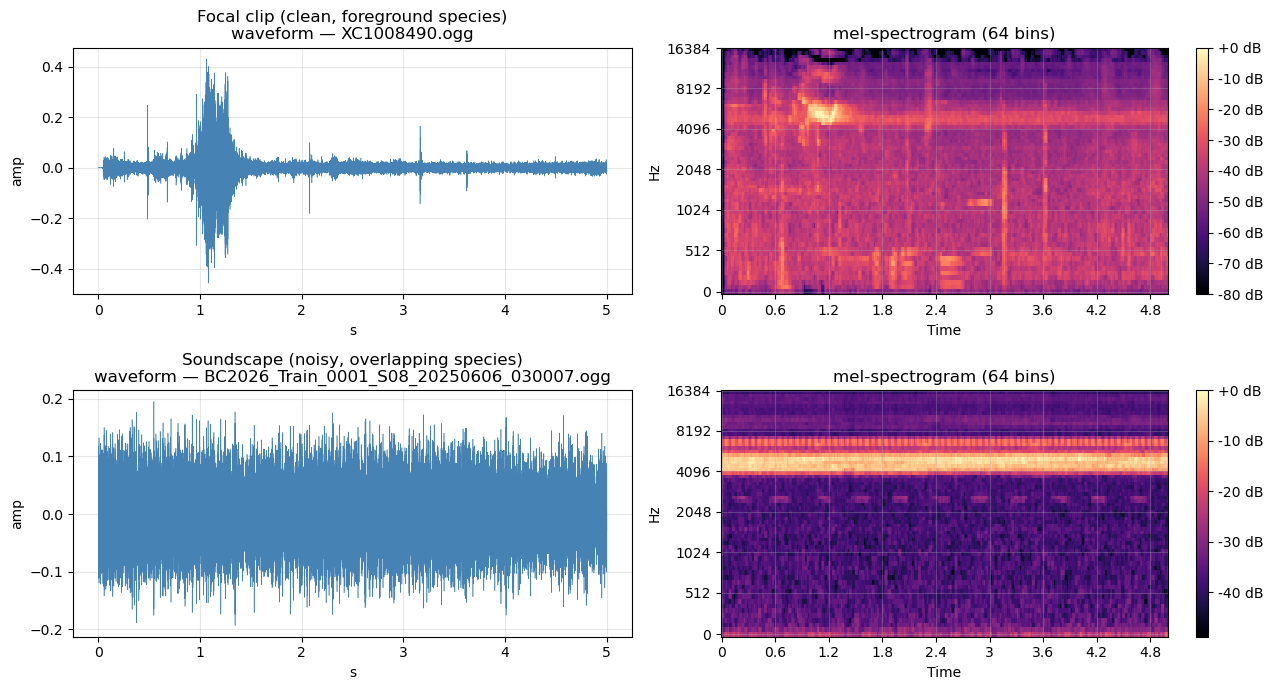

In [12]:
if HAVE_LIBROSA:
    focal_path = first_audio(TRAIN_AUDIO_DIR)
    ss_path    = first_audio(SS_AUDIO_DIR)
    samples = [('Focal clip (clean, foreground species)', focal_path),
               ('Soundscape (noisy, overlapping species)', ss_path)]

    fig, axes = plt.subplots(2, 2, figsize=(13, 7))
    for r, (title, path) in enumerate(samples):
        if path is None:
            axes[r, 0].set_title(f'{title} — no local file'); axes[r, 1].axis('off'); continue
        audio = load_clip(path)
        axes[r, 0].plot(np.linspace(0, DURATION, len(audio)), audio, lw=0.4, color='steelblue')
        axes[r, 0].set_title(f'{title}\nwaveform — {os.path.basename(path)}')
        axes[r, 0].set_xlabel('s'); axes[r, 0].set_ylabel('amp')
        img = librosa.display.specshow(mel_db(audio), sr=SAMPLE_RATE, x_axis='time',
                                       y_axis='mel', fmax=F_MAX, ax=axes[r, 1])
        axes[r, 1].set_title(f'mel-spectrogram ({N_MELS} bins)')
        fig.colorbar(img, ax=axes[r, 1], format='%+2.0f dB')
    plt.tight_layout(); plt.show()
else:
    print('Skipped (librosa unavailable).')

## 9. Key takeaways for modelling

1. **Multi-taxa, not just birds.** 234 targets across Aves / Amphibia / Insecta / Mammalia / Reptilia. One shared spectrogram model must cover very different acoustic structures.
2. **Severe class imbalance + long tail.** Many species have very few focal recordings. Because scoring is **macro** ROC-AUC, the rare tail dominates the score — motivating focal loss and augmentation (mixup / SpecAugment) over plain BCE.
3. **Genuinely multi-label.** Both focal clips (secondary labels) and soundscape windows (multiple simultaneous species) require independent per-species sigmoids, never softmax.
4. **Domain shift is the core challenge.** Clean, worldwide, single-species focal clips → noisy, Pantanal-only, multi-species soundscapes. Almost no training data originates in the test region. This is exactly why the **soundscape-validation regime** (validating on held-out soundscapes) tracks the leaderboard far better than focal-clip validation — the 0.93 clip-val → 0.71 LB gap is this shift.
5. **Label noise.** A large share of clips are unrated/low-rated and span heterogeneous sources, adding noise the model must be robust to.

*These observations directly justify the architecture and training choices documented in `APPROACH.md`.*